In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import train_score_network, generate_initial_data, rollout, time_reversal, noise, time_reversal_bsde, train_phi_network
from network import ScoreNetwork, PhiNetwork
from toy_data import inf_train_gen

In [2]:
N = 10000  # number of samples
n = 2    # dimension of state
m = 2    # dimension of noise
T = 1.0   # terminal time
steps = 100  # number of time steps
dt = T / steps  # time step size


In [3]:
# INITIAL_DIST = 'Bimodal'  # 'Gaussian' or 'Bimodal'
# shift = 3.0
# m_0 = torch.tensor([0.0])  # Mean of initial distribution
# sigma_0 = torch.eye(n) * 1  # Covariance of initial distribution

In [4]:
X_0 = torch.tensor(inf_train_gen("moons", batch_size=N))
time_grid = torch.arange(0, steps+1) * dt

In [5]:
a = -2.0
sigma = 2

In [6]:
X = torch.zeros((steps+1, N, n))
X[0] = X_0

In [7]:
for i in range(steps):
    X[i+1] = X[i] + a * X[i] * dt + sigma * noise(dt, N, m)

Text(0.5, 0, 'Time Steps')

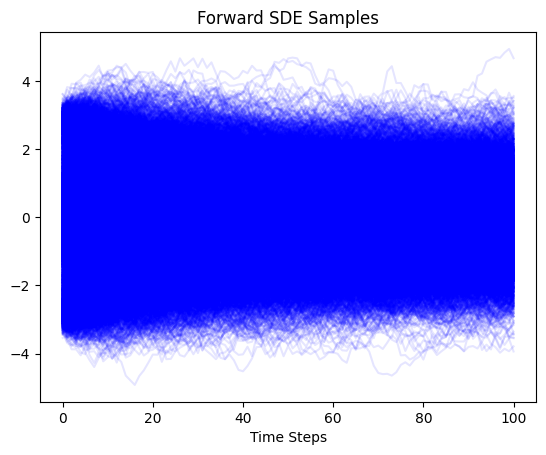

In [8]:
plt.figure()
plt.plot(X[:, :, 0].numpy(), alpha=0.1, color='blue')
plt.title('Forward SDE Samples')
plt.xlabel('Time Steps')

Text(0.5, 1.0, 'Terminal Distribution Samples')

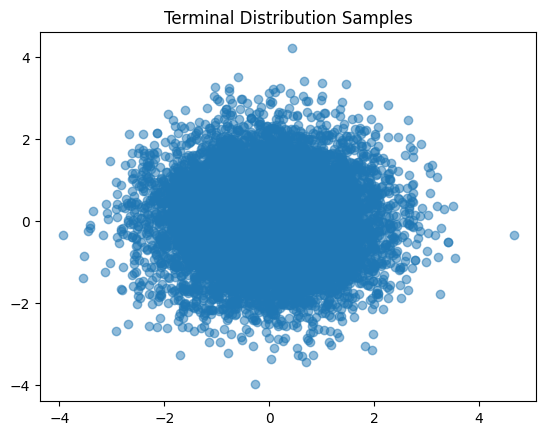

In [9]:
plt.figure()
plt.scatter(X[-1, :, 0].numpy(), X[-1, :, 1].numpy(), alpha=0.5)
plt.title('Terminal Distribution Samples')

Text(0.5, 1.0, 'Initial Distribution Samples')

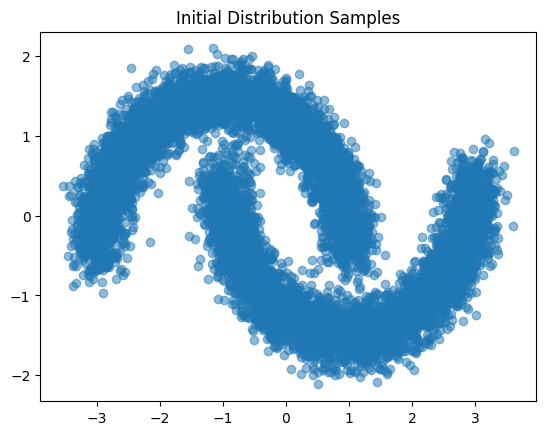

In [10]:
plt.figure()
plt.scatter(X[0, :, 0].numpy(), X[0, :, 1].numpy(), alpha=0.5)
plt.title('Initial Distribution Samples')

In [11]:
X[-1].mean(dim=0), X[-1].std(dim=0)

(tensor([-0.0110,  0.0025]), tensor([1.0297, 1.0110]))

In [12]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
score_optimizer = torch.optim.AdamW(score_nn.parameters(), lr=1e-3, weight_decay=1e-4)
score_scheduler = torch.optim.lr_scheduler.StepLR(score_optimizer, step_size=500, gamma=0.9)

In [13]:
def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.eye(n) * sigma
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

In [14]:
score_loss_history = train_score_network(score_nn, X, time_grid, g, 1, score_optimizer, score_scheduler, batch_size=64, iterations=20000)

Iteration 0, Loss: 0.01511533372104168
Iteration 500, Loss: -1.6784615516662598
Iteration 1000, Loss: -1.7197184562683105
Iteration 1500, Loss: -1.9456264972686768
Iteration 2000, Loss: -1.9843276739120483
Iteration 2500, Loss: -3.9903783798217773
Iteration 3000, Loss: -2.23728084564209
Iteration 3500, Loss: -2.695125102996826
Iteration 4000, Loss: -2.325406074523926
Iteration 4500, Loss: -4.650867938995361
Iteration 5000, Loss: -2.6133456230163574
Iteration 5500, Loss: -2.1582534313201904
Iteration 6000, Loss: -3.721736192703247
Iteration 6500, Loss: -2.8984017372131348
Iteration 7000, Loss: -2.196810722351074
Iteration 7500, Loss: -4.327925682067871
Iteration 8000, Loss: -2.0715320110321045
Iteration 8500, Loss: -2.3132951259613037
Iteration 9000, Loss: -2.8681447505950928
Iteration 9500, Loss: -3.1185529232025146
Iteration 10000, Loss: -2.232452392578125
Iteration 10500, Loss: -2.344407796859741
Iteration 11000, Loss: -2.9680140018463135
Iteration 11500, Loss: -3.610769748687744
Ite

In [15]:
time_grid.shape

torch.Size([101])

In [81]:
sample_steps = 100

In [82]:
# time reversal
X_rev = torch.zeros((sample_steps+1, N, n))
X_rev[-1] = torch.randn((N,n))

In [83]:
time_grid_sample = torch.linspace(0, T, sample_steps+1)

In [84]:
for i in range(sample_steps-1, -1, -1):
    t = time_grid_sample[i+1].repeat(N, 1)  # (N, 1)
    score = score_nn(X_rev[i+1,:,:], t).detach()  # (N, n)
    X_rev[i] = X_rev[i+1] - a * X_rev[i+1] * dt + 1.0*sigma * noise(dt, N, m) + sigma**2 * score * dt

Text(0.5, 0, 'Time Steps')

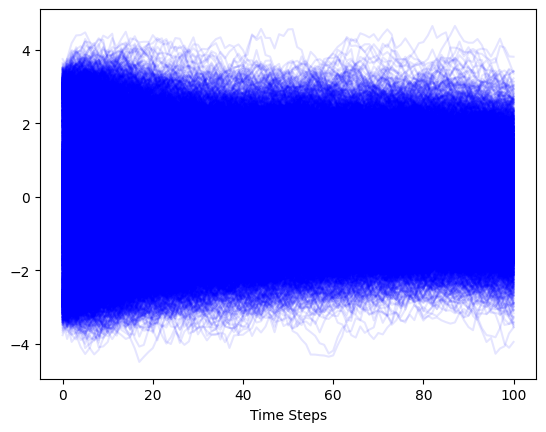

In [85]:
plt.figure()
plt.plot(X_rev[:, :, 0].numpy(), alpha=0.1, color='blue')
# plt.plot(X[:, :, 0].numpy(), alpha=0.1, color='red')
# plt.title('Backward SDE Samples')
plt.xlabel('Time Steps')

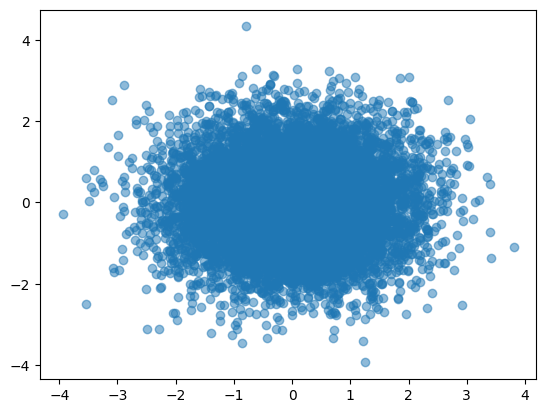

In [86]:
plt.figure()
plt.scatter(X_rev[-1, :, 0].numpy(), X_rev[-1, :, 1].numpy(), alpha=0.5)

In [87]:
from utils import MMD, kernel

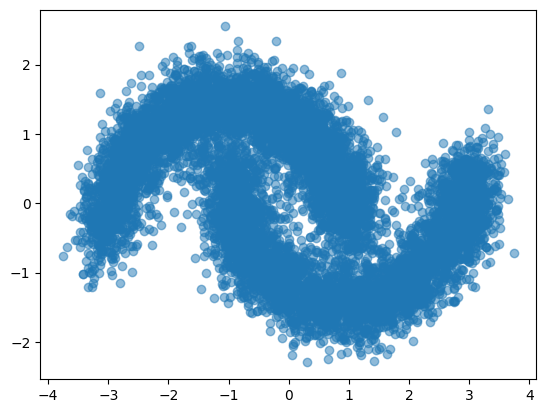

In [88]:
plt.figure()
plt.scatter(X_rev[0, :, 0].numpy(), X_rev[0, :, 1].numpy(), alpha=0.5)

In [89]:
MMD(X[0], X_rev[0], kernel)

tensor(0.0594)

In [92]:
torch.save(score_nn.state_dict(), f'network/2dim_moons_score_network_timesteps{steps}.pth')